In [1]:
data_path = "/kaggle/input/datasets/armageddon47/hyperspectral-data-indian-pines"
import os
for root, direc, files in os.walk(data_path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/armageddon47/hyperspectral-data-indian-pines/Indian_pines_corrected.mat
/kaggle/input/datasets/armageddon47/hyperspectral-data-indian-pines/Indian_pines_gt.mat


In [2]:
path_indian_pines_corrected = "/kaggle/input/datasets/armageddon47/hyperspectral-data-indian-pines/Indian_pines_corrected.mat"
path_indian_pines_gt = "/kaggle/input/datasets/armageddon47/hyperspectral-data-indian-pines/Indian_pines_gt.mat"

import scipy.io
data_set = scipy.io.loadmat(path_indian_pines_corrected)
gt = scipy.io.loadmat(path_indian_pines_gt)

print(data_set.keys())
print(gt.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])
dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])


In [3]:
print(data_set['indian_pines_corrected'].shape)
print(gt['indian_pines_gt'].shape)

(145, 145, 200)
(145, 145)


In [4]:
import numpy as np
gt_arr = np.array(gt['indian_pines_gt'])
print(gt_arr)

[[3 3 3 ... 0 0 0]
 [3 3 3 ... 0 0 0]
 [3 3 3 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [5]:
print(np.unique(gt_arr, return_counts = True))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
      dtype=uint8), array([10776,    46,  1428,   830,   237,   483,   730,    28,   478,
          20,   972,  2455,   593,   205,  1265,   386,    93]))


In [6]:
#Hyperspectral cube
cube = data_set['indian_pines_corrected']
print(cube[0,0,:]) #all band value for the first pixel
print(gt_arr[0,0])

[3172 4142 4506 4279 4782 5048 5213 5106 5053 4750 4816 4769 4610 4805
 4828 4861 4767 4624 4549 4463 4462 4446 4445 4336 4381 4319 4207 4305
 4311 3991 4168 3942 4061 4362 4318 4252 4869 5284 5055 3591 5175 5217
 5058 4969 4721 4291 4555 4886 4868 4806 4783 4811 4709 3903 3795 3715
 2591 2130 2269 2480 3145 3626 4060 4296 4211 4225 4157 4133 4082 4048
 3935 3843 3784 3642 3271 2707 1707 1564 1838 1719 2229 2764 2919 2873
 2977 2913 3034 3051 3124 3101 3033 2713 2740 2947 2706 2834 2856 2683
 2400 2229 1822 1542 1097 1047 1069 1100 1122 1259 1365 1261 1374 1630
 1851 2028 2130 2170 2205 2214 2204 2100 2106 2146 2089 2078 2134 2127
 2074 2057 2045 2003 1999 1959 1924 1883 1843 1781 1716 1698 1645 1540
 1410 1294 1131 1044 1032 1045 1100 1212 1295 1244 1100 1103 1216 1346
 1330 1259 1251 1313 1372 1393 1402 1396 1381 1396 1381 1353 1346 1341
 1332 1324 1310 1318 1330 1310 1292 1280 1275 1266 1264 1233 1241 1232
 1215 1215 1187 1168 1171 1150 1134 1123 1135 1094 1090 1112 1090 1062
 1069 

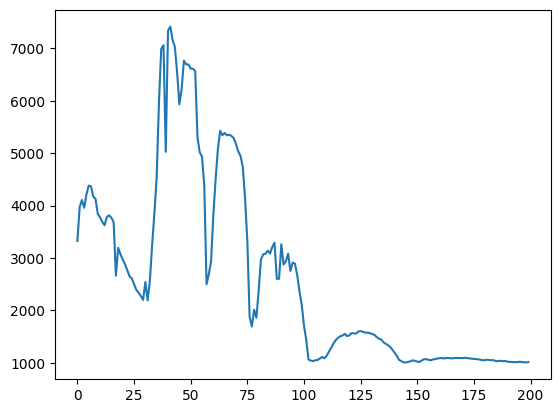

In [7]:
import matplotlib.pyplot as plt
spectrum = cube[120,120,:]
plt.plot(spectrum)

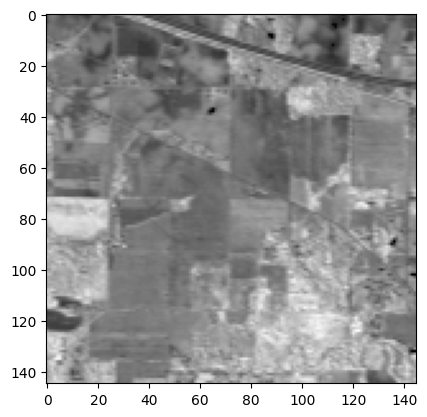

In [8]:
#visualizing each spectral band at a time
plt.imshow(cube[:,:,50], cmap='gray')

In [9]:
mask = gt_arr > 0
x = cube[mask]
y = gt_arr[mask]

print(np.unique(y, return_counts = True))
print(x.shape)
print(y.shape)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
      dtype=uint8), array([  46, 1428,  830,  237,  483,  730,   28,  478,   20,  972, 2455,
        593,  205, 1265,  386,   93]))
(10249, 200)
(10249,)


In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size = 0.75, stratify=y, random_state=69)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print(np.unique(y_test, return_counts=True))

(7686, 200)
(2563, 200)
(7686,)
(2563,)
(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
      dtype=uint8), array([ 11, 357, 208,  59, 121, 183,   7, 120,   5, 243, 614, 148,  51,
       316,  97,  23]))


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

print(x_train_std.shape)
print(x_test_std.shape)

(7686, 200)
(2563, 200)


In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm = SVC(kernel='rbf')
svm.fit(x_train_std, y_train)
y_pred = svm.predict(x_test_std)

In [13]:
print(accuracy_score(y_test, y_pred))

0.8127194693718299


In [14]:
print(confusion_matrix(y_test, y_pred))

[[  0   0   0   0   0   0   0  10   0   0   1   0   0   0   0   0]
 [  0 272   3   3   0   0   0   0   0  23  54   2   0   0   0   0]
 [  0  11 112   3   0   0   0   0   0   0  67  15   0   0   0   0]
 [  0  16   6  22   0   3   0   1   0   1  10   0   0   0   0   0]
 [  0   1   0   1 107   2   0   0   0   0   1   0   0   9   0   0]
 [  0   0   0   0   0 181   0   0   0   0   0   0   0   0   2   0]
 [  0   0   0   0   0   0   0   7   0   0   0   0   0   0   0   0]
 [  0   0   0   0   1   0   0 119   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   4   0   0   0   0   0   0   1   0   0   0]
 [  0   9   3   0   0   0   0   0   0 171  57   3   0   0   0   0]
 [  0  27   3   2   0   2   0   1   0  14 561   3   0   0   1   0]
 [  0  10   8   7   0   0   0   0   0   6  14 102   0   0   0   1]
 [  0   0   0   0   0   0   0   0   0   0   0   0  51   0   0   0]
 [  0   0   0   0   1   0   0   0   0   0   0   0   0 313   2   0]
 [  0   0   0   0   3  13   0   0   0   2   0   0   4  24  51 

In [15]:
print(classification_report(y_test, y_pred, zero_division = 0))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.79      0.76      0.77       357
           3       0.83      0.54      0.65       208
           4       0.58      0.37      0.45        59
           5       0.96      0.88      0.92       121
           6       0.88      0.99      0.93       183
           7       0.00      0.00      0.00         7
           8       0.86      0.99      0.92       120
           9       0.00      0.00      0.00         5
          10       0.78      0.70      0.74       243
          11       0.73      0.91      0.81       614
          12       0.82      0.69      0.75       148
          13       0.91      1.00      0.95        51
          14       0.90      0.99      0.95       316
          15       0.91      0.53      0.67        97
          16       0.95      0.91      0.93        23

    accuracy                           0.81      2563
   macro avg       0.68   

In [16]:
svm_poly = SVC(kernel="poly", degree=3)
svm_poly.fit(x_train_std, y_train)
y_pred_poly = svm_poly.predict(x_test_std)
print(accuracy_score(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))

0.7292235661334374
[[  0   0   0   0   0   0   0  10   0   0   1   0   0   0   0   0]
 [  0 189   1   1   0   0   0   0   0  21 145   0   0   0   0   0]
 [  0   7  29   6   0   0   0   0   0   0 157   9   0   0   0   0]
 [  0   8   1  20   0   3   0   2   0   0  25   0   0   0   0   0]
 [  0   0   0   0 109   1   0   1   0   0   9   0   0   1   0   0]
 [  0   0   0   0   0 179   0   0   0   0   3   0   0   0   1   0]
 [  0   0   0   0   0   0   0   1   0   0   6   0   0   0   0   0]
 [  0   0   0   0   0   0   0 110   0   0  10   0   0   0   0   0]
 [  0   0   0   0   0   3   0   0   0   0   2   0   0   0   0   0]
 [  0   6   2   0   0   0   0   0   0 156  79   0   0   0   0   0]
 [  0  15   0   0   1   2   0   0   0  13 578   5   0   0   0   0]
 [  0  21   1   3   0   0   0   0   0   5  59  59   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  51   0   0   0]
 [  0   0   0   0   1   0   0   0   0   0   0   0   0 310   5   0]
 [  0   0   0   0   5  15   0   0   0   0  

In [17]:
print(classification_report(y_test, y_pred_poly, zero_division=0))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.77      0.53      0.63       357
           3       0.85      0.14      0.24       208
           4       0.67      0.34      0.45        59
           5       0.94      0.90      0.92       121
           6       0.88      0.98      0.93       183
           7       0.00      0.00      0.00         7
           8       0.89      0.92      0.90       120
           9       0.00      0.00      0.00         5
          10       0.80      0.64      0.71       243
          11       0.54      0.94      0.68       614
          12       0.81      0.40      0.53       148
          13       1.00      1.00      1.00        51
          14       0.95      0.98      0.96       316
          15       0.90      0.59      0.71        97
          16       1.00      0.96      0.98        23

    accuracy                           0.73      2563
   macro avg       0.69   

In [18]:
#apply pca
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99)
x_train_pca = pca.fit_transform(x_train_std)
x_test_pca = pca.transform(x_test_std)

In [19]:
print(x_train_std.shape)
print(x_train_pca.shape)
print(x_test_std.shape)
print(x_test_pca.shape)

(7686, 200)
(7686, 38)
(2563, 200)
(2563, 38)


In [20]:
print(pca.explained_variance_ratio_)

[6.86741783e-01 1.89391666e-01 2.93081521e-02 1.73771699e-02
 1.17435730e-02 6.50539402e-03 4.53864390e-03 3.99323039e-03
 3.73550631e-03 3.48054128e-03 2.78848294e-03 2.48656009e-03
 2.25055495e-03 2.10910758e-03 2.02339849e-03 1.88648439e-03
 1.59116680e-03 1.55862076e-03 1.50093820e-03 1.38104507e-03
 1.27849481e-03 1.16453677e-03 1.08229310e-03 1.05234410e-03
 9.56550759e-04 8.71990783e-04 8.35387361e-04 7.93318386e-04
 7.61024152e-04 7.10816101e-04 6.69737321e-04 6.46210102e-04
 5.99071601e-04 5.81412963e-04 5.65055796e-04 5.22838801e-04
 4.74694036e-04 4.67035017e-04]


In [21]:
svm_pca = SVC(kernel="rbf")
svm_pca.fit(x_train_pca, y_train)
y_pred_pca = svm_pca.predict(x_test_pca)
print(accuracy_score(y_test, y_pred_pca))

0.7920405774483028


In [22]:
print(confusion_matrix(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca, zero_division=0))

[[  0   0   0   0   0   0   0  10   0   0   1   0   0   0   0   0]
 [  0 259   2   3   0   0   0   0   0  25  64   4   0   0   0   0]
 [  0  11 107   3   0   0   0   0   0   0  72  15   0   0   0   0]
 [  0  17   3  22   0   3   0   1   0   1  12   0   0   0   0   0]
 [  0   1   0   1 106   2   0   0   0   0   1   0   0  10   0   0]
 [  0   0   0   0   0 179   0   0   0   0   0   0   0   2   2   0]
 [  0   0   0   0   0   0   0   7   0   0   0   0   0   0   0   0]
 [  0   0   0   0   1   0   0 119   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   4   0   0   0   0   0   0   1   0   0   0]
 [  0   8   3   0   0   0   0   0   0 171  58   3   0   0   0   0]
 [  0  37   3   1   0   3   0   1   0  15 550   4   0   0   0   0]
 [  0  12   8   7   0   0   0   0   0   7  22  91   0   0   0   1]
 [  0   0   0   0   0   0   0   0   0   0   0   0  51   0   0   0]
 [  0   0   0   0   2   0   0   0   0   0   0   0   0 312   2   0]
 [  0   0   0   0   4  16   0   0   0   2   0   0   7  26  42 

In [23]:
from sklearn.model_selection import GridSearchCV
param_grid = {
              "C": [0.1, 1, 10],
              "gamma": [0.01, 0.1, 1]
             }

In [24]:
svm_grid = GridSearchCV(
                        estimator=SVC(kernel="rbf"),
                        param_grid = param_grid,
                        cv=3,
                        scoring = "accuracy",
                        n_jobs=-1
                        )

svm_grid.fit(x_train_std, y_train)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]},
             scoring='accuracy')

In [25]:
print(svm_grid.best_params_)
print(svm_grid.best_score_)

{'C': 10, 'gamma': 0.01}
0.8929221962008848


In [26]:
svm_best = svm_grid.best_estimator_

In [27]:
y_pred_grid = svm_best.predict(x_test_std)
print(accuracy_score(y_test, y_pred_grid))
print(confusion_matrix(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid, zero_division=0))

0.9133827545844713
[[  9   0   0   0   0   0   0   1   0   1   0   0   0   0   0   0]
 [  0 319   5   3   0   0   0   0   0   6  21   3   0   0   0   0]
 [  0   6 169   6   0   0   0   0   0   1  21   5   0   0   0   0]
 [  0   3   2  50   0   0   0   1   0   1   2   0   0   0   0   0]
 [  0   0   0   1 116   1   0   0   0   0   2   0   0   1   0   0]
 [  0   0   0   0   0 182   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0   0   0   0   6   1   0   0   0   0   0   0   0   0]
 [  1   0   0   0   2   0   0 117   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   4   0   0   0   1   0   0   0]
 [  0   9   2   0   0   0   0   0   0 208  23   1   0   0   0   0]
 [  0  20   7   2   0   1   1   0   0  14 567   2   0   0   0   0]
 [  0   4   2   2   0   0   0   0   0   1   3 134   0   0   1   1]
 [  0   0   0   0   0   0   0   0   0   0   0   0  51   0   0   0]
 [  0   0   0   0   1   0   0   0   0   0   0   0   0 310   5   0]
 [  0   0   0   0   2   4   0   0   0   1  

default hyperparameters were poorly suited for this specific class-imbalance structure, and tuning gave minority classes a real chance by finding a boundary shape that doesn't just optimize for the dominant classes.